In [2]:
import scqubits
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'

# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


In [3]:
# scqubits.GUI()

# demo plot circuit

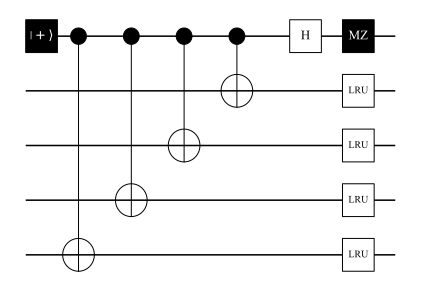

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Define the circuit's grid
fig, ax = plt.subplots(figsize=(7.3, 5))
lines = ['d_D', 'd_R', 'd_L', 'd_U', 'a_z']
for i, line in enumerate(lines):
    ax.hlines(y=i, xmin=0, xmax=7, color='black',zorder=0)

# Qubit initialization box
ax.add_patch(Rectangle((0, 3.7), width=0.6, height=0.6, fill=True, color='black', label='Qubit Init'))
ax.text(0.3, 4, r'$\left|+\right>$', color='white', ha='center', va='center',fontsize = 13)

# Measurement box
ax.add_patch(Rectangle((6, 3.7), width=0.6, height=0.6, fill=True, color='black', label='Measurement'))
ax.text(6.3, 4, 'MZ', color='white', ha='center', va='center',fontsize = 13)



# Controlled operations (dots and vertical lines)
for i in range(4, 0, -1):
    ax.add_patch(plt.Circle((i, 4), 0.15, color='black'))
    ax.add_line(Line2D([i, i], [i-1-0.3, 4.1], color='black', linewidth=1))
    ax.add_patch(plt.Circle((i, i-1), 0.3, color='black',fill= False))

# LRU boxes
for i in range(0, 4):
    ax.add_patch(Rectangle((6, i-0.3), width=0.6, height=0.6, angle=0, fill=True, facecolor='white', edgecolor='black'))
    ax.text(6.3, i, 'LRU', color='black', ha='center', va='center')

# H gate
ax.add_patch(Rectangle((5, 3.7), width=0.6, height=0.6, fill=True,facecolor='white', edgecolor='black', label='H'))
ax.text(5.3, 4, 'H', color='black', ha='center', va='center',fontsize = 13)


# Remove the axes
ax.axis('off')
plt.savefig("fig_slides_circ.png", format='png', bbox_inches='tight')

plt.show()


# demo plot for no false positive

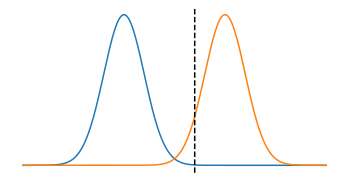

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Define the parameters for the bell curves
mean1, mean2 = 0, 5  # Different means
variance = 1
sigma = np.sqrt(variance)  # Standard deviation

# Create a range of x values from -10 to 15
x = np.linspace(-5, 10, 1000)

# Create the two bell curves (Gaussian distributions)
y1 = stats.norm.pdf(x, mean1, sigma)
y2 = stats.norm.pdf(x, mean2, sigma)

# Plotting the curves
plt.figure(figsize=(6, 3))
plt.plot(x, y1, label=f'Mean = {mean1}')
plt.plot(x, y2, label=f'Mean = {mean2}')

plt.axvline(x=3.5, color='k', linestyle='--')

# plt.title('Two Gaussian Distributions with Same Variance but Different Means')
# plt.xlabel('X')
# plt.ylabel('Probability Density')
# plt.legend()
# plt.grid(True)
# Disable xticks and yticks
plt.xticks([])
plt.yticks([])

# Remove the top, right, bottom, and left spines (borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)


plt.savefig("fig_slides_no_false_positive.png", format='png', bbox_inches='tight')

plt.show()


# Fig 1 matrix element swept over external flux

In [86]:
fluxonium = scqubits.Fluxonium(EJ = 3,EC=0.6,EL=0.13,flux=0,cutoff=110)
flux_vals = np.linspace(-0.005,0.005,100)
spectrumdata_1 = fluxonium.get_matelements_vs_paramvals(operator = 'n_operator',param_name = 'flux',param_vals=flux_vals,evals_count = 3)  # spectrumdata.matrixelem_table is of shape (num_vals_for_swept_param, num_levels, num_levels)


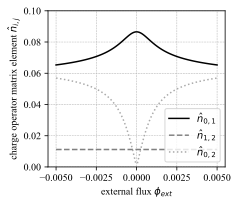

In [92]:
data = spectrumdata_1.matrixelem_table

# Extracting Y values for each curve
y_values_01 = np.array([abs(array[0, 1]) for array in data])
y_values_12 = np.array([abs(array[1, 2]) for array in data])
y_values_02 = np.array([abs(array[0, 2]) for array in data])

# Plotting
plt.figure(figsize=(3+3/8,3))
plt.plot(flux_vals, y_values_01, linestyle='-', color='black', label=r'$\hat{n}_{0,1}$',linewidth = 1.5)#, marker='o', markevery=10)
plt.plot(flux_vals, y_values_12, linestyle='--', color='gray', label=r'$\hat{n}_{1,2}$',linewidth = 1.5)#, marker='^', markevery=10)
plt.plot(flux_vals, y_values_02, linestyle=':', color='darkgray', label=r'$\hat{n}_{0,2}$',linewidth = 1.5)#, marker='s', markevery=10)
plt.ylim(0, 0.1)

plt.xlabel(r'external flux $\phi_{ext}$')
plt.ylabel(r'charge operator matrix element $\hat{n}_{i,j}$')
# plt.title('Charge Matrix Element', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.savefig("fig01_matrix_ele.pdf", format='pdf', bbox_inches='tight')

plt.show()

# Fig 2 energy specturm swept over external flux

In [88]:
fluxonium = scqubits.Fluxonium(EJ = 3,EC=0.6,EL=0.13,flux=0,cutoff=110)
flux_vals = np.linspace(-0.005,0.005,100)
spectrumdata_2 = fluxonium.get_spectrum_vs_paramvals(param_name = 'flux',param_vals=flux_vals,evals_count = 3)  # spectrumdata.matrixelem_table is of shape (num_vals_for_swept_param, num_levels, num_levels)
# spectrumdata.energy_table is a tuple of len 100, each element is three energies

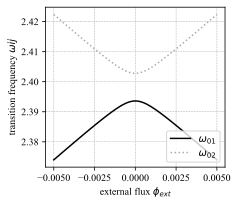

In [93]:

data = spectrumdata_2.energy_table

# Extracting Y values for each curve
y_values_01 = np.array([array[1]-array[0] for array in data])
y_values_02 = np.array([array[2]-array[0] for array in data])

# Plotting
plt.figure(figsize=(3+3/8,3))
plt.plot(flux_vals, y_values_01, linestyle='-', color='black', label=r'$\omega_{01}$',linewidth = 1.5)#, marker='o', markevery=10)
plt.plot(flux_vals, y_values_02, linestyle=':', color='darkgray', label=r'$\omega_{02}$',linewidth = 1.5)#, marker='s', markevery=10)

plt.xlabel(r'external flux $\phi_{ext}$')
plt.ylabel(r'transition frequency $\omega{ij}$')
# plt.title('Transition frequencies', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.savefig("fig02_frequencies.pdf", format='pdf', bbox_inches='tight')

plt.show()